# Cross-Validation and AUCs of LRM per cell line idea (unique drug-indication pairs)

## *1. Import the DRH and clinical trials datasets*

In [1]:
# import data manipulation tools
import pandas as pd
import numpy as np

In [2]:
### initialize dictionaries to store the DRH and clinical datasets
DRH_data = {}
clin_data = {}
### store a list of the cell lines used
cell_lines = ["A375", "MCF7", "PC3"]

### iterate through each cell line
for cell_line in cell_lines:
    ## store the DRH and clinical datasets in their respective dictionaries
    file_path = "~/LINCS/LRM_unique_ind/ref_data/DRH_data/" + cell_line + "_unique_ind.txt"
    DRH_data[cell_line] = pd.read_csv(file_path)
    
    file_path = "~/LINCS/LRM_unique_ind/ref_data/clin_data/" + cell_line + "_unique_ind.txt"
    clin_data[cell_line] = pd.read_csv(file_path)

DRH_data["MCF7"].head()

,drug1,drug1 tas,drug2,drug2 tas,spearman corr,indication,known ind
0,midostaurin,0.799386,altrenogest,0.812819,0.908978,Estrus,False
1,altrenogest,0.812819,midostaurin,0.799386,0.908978,"Leukemia, Myeloid, Acute",False
2,ixazomib,0.791817,ixazomib-citrate,0.747696,0.889649,Multiple Myeloma,True
3,ixazomib-citrate,0.747696,ixazomib,0.791817,0.889649,Multiple Myeloma,True
4,carfilzomib,0.763093,ixazomib-citrate,0.747696,0.839315,Multiple Myeloma,True


## *2. Generate the shared data filtered by TAS cutoff*

In [3]:
### function to select only drug-indication pairs above TAS cutoff
def gen_tas_datasets(cell_line_data):
    ## initialize a dictionary to store all the filtered datasets at each tas cutoff
    tas_data = {}
    ## iterate through each tas cutoff
    for tas_cutoff in tas_cutoffs:
        ## store only drug-indication pairs below tas cutoff in the dictionary
        drug1_above_tas = cell_line_data["drug1 tas"] > tas_cutoff
        drug2_above_tas = cell_line_data["drug2 tas"] > tas_cutoff
        tas_data[tas_cutoff] = cell_line_data.loc[drug1_above_tas & drug2_above_tas]
        
    return tas_data

In [4]:
### function to get the intersection dataset for a cell line
def get_shared_data(DRH_data, clin_data, cell_line):
    ## get the DRH and clinical trials data for that cell line
    DRH = DRH_data[cell_line]
    clin = clin_data[cell_line]
    ## create a dataframe containing the rows in both datasets
    cols = DRH.columns.tolist()[:-1]
    shared_data = pd.merge(DRH, clin, on=cols, suffixes=("_DRH", "_clin"), how="inner")
    
    return shared_data

In [5]:
### initialize a dictionary to store all the shared data across all cell lines
shared_data = {}

### store a list of all tas cutoffs of interest
tas_cutoffs = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

### iterate through each cell line
for cell_line in cell_lines:
    ## get the rows present in both DRH and clinical trials
    cell_line_data = get_shared_data(DRH_data, clin_data, cell_line)
    ## generate the store the tas datasets for this shared data
    shared_data[cell_line] = gen_tas_datasets(cell_line_data)
    
shared_data["MCF7"][0.5].head()

,drug1,drug1 tas,drug2,drug2 tas,spearman corr,indication,known ind_DRH,known ind_clin
0,ixazomib,0.791817,metronidazole,0.641509,0.770292,Rosacea,False,False
1,sitagliptin,0.587846,5-aminolevulinic-acid,0.618329,0.750782,Glioma,False,False
2,5-aminolevulinic-acid,0.618329,sitagliptin,0.587846,0.750782,Diabetes Mellitus,False,False
3,sitagliptin,0.587846,5-aminolevulinic-acid,0.618329,0.750782,"Keratosis, Actinic",False,False
4,macitentan,0.561786,phenylbutyrate,0.508335,0.741032,"Urea Cycle Disorders, Inborn",False,False


### Information about the datasets

In [6]:
### function to obtain relevant information about the datasets
def gen_shared_info(shared_data, cell_line):
    ## initialize a dataframe to store the relevant information
    cols = ["TAS cutoff", "DRH rows", "# true in DRH", "% true in DRH", "# true in clin", "# neither"]
    shared_info = pd.DataFrame(columns=cols)
    
    ## iterate through each tas cutoff and dataset
    for tas_cutoff in tas_cutoffs:
        ## store the tas dataset for cell line
        tas_data = shared_data[cell_line][tas_cutoff]
        # get relevant information about the dataset
        in_DRH = tas_data["known ind_DRH"]
        in_clin = tas_data["known ind_clin"]
        only_in_clin = tas_data[~in_DRH & in_clin]
        neither = tas_data[~in_DRH & ~in_clin]
        DRH_rows = len(tas_data) - len(neither)
        # create a dictionary with the relevant information for tas cutoff
        tas_info = {"TAS cutoff": tas_cutoff,
                    "DRH rows": DRH_rows,
                    "# true in DRH": in_DRH.sum(),
                    "% true in DRH": in_DRH.sum()/float(DRH_rows)*100,
                    "# true in clin": len(only_in_clin),
                    "# neither": neither.shape[0]}
        shared_info = shared_info.append(tas_info, ignore_index=True)
        
    return shared_info

In [7]:
### initialize a dictionary to store all the information about the datasets for each cell line
shared_info = {}

### iterate through each cell line
for cell_line in cell_lines:
    ## calculate and store the relevant information about the datasets
    shared_info[cell_line] = gen_shared_info(shared_data, cell_line)

shared_info["MCF7"]

,TAS cutoff,DRH rows,# true in DRH,% true in DRH,# true in clin,# neither
0,0.20,240.0,52.0,21.666667,188.0,6235.0
1,0.25,134.0,24.0,17.910448,110.0,3172.0
2,0.30,72.0,14.0,19.444444,58.0,1206.0
3,0.35,57.0,11.0,19.298246,46.0,686.0
4,0.40,51.0,10.0,19.607843,41.0,546.0
5,0.45,44.0,8.0,18.181818,36.0,361.0
6,0.50,22.0,5.0,22.727273,17.0,194.0


In [8]:
shared_info["A375"]

,TAS cutoff,DRH rows,# true in DRH,% true in DRH,# true in clin,# neither
0,0.20,245.0,51.0,20.816327,194.0,6064.0
1,0.25,163.0,35.0,21.472393,128.0,3315.0
2,0.30,132.0,23.0,17.424242,109.0,1617.0
3,0.35,89.0,18.0,20.224719,71.0,806.0
4,0.40,59.0,15.0,25.423729,44.0,480.0
5,0.45,55.0,14.0,25.454545,41.0,390.0
6,0.50,50.0,12.0,24.000000,38.0,317.0


In [9]:
shared_info["PC3"]

,TAS cutoff,DRH rows,# true in DRH,% true in DRH,# true in clin,# neither
0,0.20,204.0,53.0,25.980392,151.0,5759.0
1,0.25,103.0,28.0,27.184466,75.0,2542.0
2,0.30,69.0,19.0,27.536232,50.0,1414.0
3,0.35,51.0,16.0,31.372549,35.0,1060.0
4,0.40,42.0,14.0,33.333333,28.0,740.0
5,0.45,37.0,12.0,32.432432,25.0,402.0
6,0.50,29.0,11.0,37.931034,18.0,285.0


## *3. Generate the training and testing datasets* 

### a. Generate training and testing datasets

In [10]:
### function to split the neithers while maintaining same percentage of 0s for tas cutoff
def split_neithers(shared_data):
    ## store whether the drug-indication pairs are in DRH and clinical trials independently
    in_DRH = shared_data["known ind_DRH"]
    in_clin = shared_data["known ind_clin"]
    ## get the drug-indications that are only in clinical trials
    only_in_clin = shared_data.loc[~in_DRH & in_clin]
    ## get the dataframe containing the other drug-indications
    DRH = shared_data.drop(only_in_clin.index)
    ## get the drug-indications that are not in either DRH or clinical trials
    neither_data = shared_data.loc[~in_DRH & ~in_clin]
    
    ## get the relevant information about the datasets
    DRH_true = DRH["known ind_DRH"].sum()
    clin_true = only_in_clin["known ind_clin"].sum()
    total_neithers = len(neither_data)
    ## calculate the number of neithers to add to clinical trials
    num2add = (clin_true*total_neithers)/(DRH_true + clin_true)
    clin_neither = neither_data.sample(n=num2add, random_state=42)
    
    return only_in_clin, DRH, clin_neither

In [11]:
### function to generate training dataset for one cell line
def gen_train_test_data(shared_data, cell_line):
    ## initialize dictionaries to store the training and testing datasets
    train = {}
    test = {}
    
    ## iterate through each tas cutoff
    for tas_cutoff in tas_cutoffs:
        ## store the dataset for that cell line and tas cutoff
        shared_tas = shared_data[cell_line][tas_cutoff]
        ## randomly split the neithers while maintaing percent trues
        only_in_clin, DRH, clin_neither = split_neithers(shared_tas)
        ## generate the training datasets
        train_tas = DRH.drop(clin_neither.index)
        train_tas = train_tas.drop(["known ind_clin"], axis=1)
        train_tas.rename(columns={"known ind_DRH": "known ind"}, inplace=True)
        ## store the training dataset in the dictionary for all tas cutoffs
        train[tas_cutoff] = train_tas

        ## generate the testing dataset
        test_tas = pd.concat([only_in_clin, clin_neither])
        test_tas = test_tas.drop(["known ind_DRH"], axis=1)
        test_tas.rename(columns={"known ind_clin": "known ind"}, inplace=True)
        ## generate the separate datasets for each TAS cutoff
        test[tas_cutoff] = test_tas
    
    return train, test

In [12]:
### initialize a dictionary to store the training datasets for each cell line
train_data = {}
test_data = {}

### iterate through each cell line
for cell_line in cell_lines:
    ## generate and store all the tas datasets for that cell line
    train, test = gen_train_test_data(shared_data, cell_line)
    train_data[cell_line] = train
    test_data[cell_line] = test
    
train_data["MCF7"][0.5].head()

,drug1,drug1 tas,drug2,drug2 tas,spearman corr,indication,known ind
1,sitagliptin,0.587846,5-aminolevulinic-acid,0.618329,0.750782,Glioma,False
12,valrubicin,0.794730,doxorubicin,0.732233,0.725946,Urinary Bladder Neoplasms,True
14,doxorubicin,0.732233,valrubicin,0.794730,0.725946,Urinary Bladder Neoplasms,True
16,valrubicin,0.794730,doxorubicin,0.732233,0.725946,"Leukemia, Myeloid, Acute",False
19,palbociclib,0.575843,lurasidone,0.566841,0.712300,Schizophrenia,False


In [13]:
test_data["MCF7"][0.5].head()

,drug1,drug1 tas,drug2,drug2 tas,spearman corr,indication,known ind
5,metronidazole,0.641509,sitagliptin,0.587846,0.727970,Diabetes Mellitus,True
33,belinostat,0.672252,romidepsin,0.795148,0.692400,"Lymphoma, T-Cell, Cutaneous",True
34,romidepsin,0.795148,belinostat,0.672252,0.692400,"Lymphoma, T-Cell, Peripheral",True
49,mepacrine,0.806568,crizotinib,0.670493,0.676249,"Carcinoma, Non-Small-Cell Lung",True
144,amsacrine,0.660436,mitoxantrone,0.681046,0.610274,"Leukemia, Myeloid, Acute",True


### Information about the datasets

In [14]:
### function to generate a dataframe summarizing relevant information about the datasets
def gen_dataset_info(data):
    ## initialize a dictionary to store the dataframes across all cell lines
    data_info = {}
    ## iterate through each cell line
    for cell_line in cell_lines:
        ## initialize an empty dataframe to store the information
        cols = ["TAS cutoff", "# cps", "# drug-indication pairs", "# true", "% true"]
        cell_line_info = pd.DataFrame(columns=cols)
        ## and tas cutoff
        for tas_cutoff in tas_cutoffs:
            # get the dataset for that tas cutoff and cell line
            tas_data = data[cell_line][tas_cutoff]
            # create a dictionary containing the information for the tas dataset
            row2add = {"TAS cutoff": tas_cutoff,
                       "# cps": tas_data["drug1"].nunique(),
                       "# drug-indication pairs": len(tas_data),
                       "# true": len(tas_data.loc[tas_data["known ind"] == 1])}
            row2add["% true"] = row2add["# true"]/float(row2add["# drug-indication pairs"])*100
            # add this as a row to the dataframe
            cell_line_info = cell_line_info.append(row2add, ignore_index=True)
        ## store the tas datasets for that cell line in the dictionary
        data_info[cell_line] = cell_line_info
        
    return data_info

In [15]:
# summarize relevant information about the DRH datasets
train_info = gen_dataset_info(train_data)
train_info["MCF7"]

,TAS cutoff,# cps,# drug-indication pairs,# true,% true
0,0.20,268.0,1403.0,52.0,3.706344
1,0.25,169.0,593.0,24.0,4.047218
2,0.30,110.0,249.0,14.0,5.622490
3,0.35,68.0,144.0,11.0,7.638889
4,0.40,57.0,118.0,10.0,8.474576
5,0.45,46.0,74.0,8.0,10.810811
6,0.50,32.0,50.0,5.0,10.000000


In [16]:
# summarize relevant information about the clinical trials datasets
test_info = gen_dataset_info(test_data)
test_info["MCF7"]

,TAS cutoff,# cps,# drug-indication pairs,# true,% true
0,0.20,268.0,5072.0,188.0,3.706625
1,0.25,179.0,2713.0,110.0,4.054552
2,0.30,124.0,1029.0,58.0,5.636540
3,0.35,88.0,599.0,46.0,7.679466
4,0.40,73.0,479.0,41.0,8.559499
5,0.45,59.0,331.0,36.0,10.876133
6,0.50,43.0,166.0,17.0,10.240964


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
train_data["MCF7"][0.2].head()

,drug1,drug1 tas,drug2,drug2 tas,spearman corr,indication,known ind
3,sitagliptin,0.587846,5-aminolevulinic-acid,0.618329,0.750782,"Keratosis, Actinic",False
4,macitentan,0.561786,phenylbutyrate,0.508335,0.741032,"Urea Cycle Disorders, Inborn",False
6,sitagliptin,0.587846,metronidazole,0.641509,0.727970,Rosacea,False
10,valrubicin,0.794730,doxorubicin,0.732233,0.725946,Hodgkin Disease,False
12,valrubicin,0.794730,doxorubicin,0.732233,0.725946,Urinary Bladder Neoplasms,True


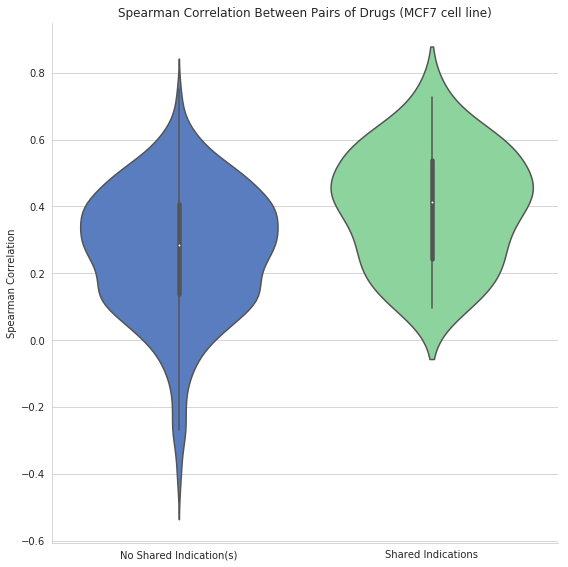

In [19]:
# show a violin plot comparing the spearman correlation between pairs of drugs for MCF7 cell line
sns.set_style("whitegrid")
colors = [sns.color_palette("muted")[0], "#81df96"]
sns.catplot(data=train_data["MCF7"][0.2],
            x = "known ind",
            y = "spearman corr",
            kind = "violin",
            palette = colors,
            height=8)

# add labels
plt.title("Spearman Correlation Between Pairs of Drugs (MCF7 cell line)")
plt.xlabel("")
plt.xticks([0,1], ["No Shared Indication(s)", "Shared Indications"])
plt.ylabel("Spearman Correlation")
plt.show() 

## *4. Evaluate Model*

### a. Cross-Validation

In [20]:
# import the data modeling and evaluation tools
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, roc_curve, roc_auc_score, precision_score, recall_score, f1_score

# import data visualization tools
import matplotlib.pyplot as plt

In [21]:
# initialize the parameters of the logistic regression model
lrm = LogisticRegression(class_weight="balanced", solver="lbfgs", random_state=42)

# intialize the parameters of the Stratified KFold
skf = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

# create a dictionary to define the evaluation metrics of interest
metrics = {"AUC": make_scorer(roc_auc_score),
           "precision": make_scorer(precision_score),
           "recall": make_scorer(recall_score),
           "F1 score": make_scorer(f1_score)}

In [22]:
### function to perform cross-validation for one cell line
def gen_cv_scores(train_data, cell_line):
    ## initialize dataframe to store the evaluation metrics for training and validations datasets
    cv_scores = pd.DataFrame()
    ## iterate through the tas cutoffs
    for tas_cutoff in tas_cutoffs:
        # store the tas dataset
        tas_data = train_data[cell_line][tas_cutoff]
        # define the inputs and outputs to train the model
        train_cols = ["drug1 tas", "drug2 tas", "spearman corr"]
        X, y = tas_data[train_cols], tas_data["known ind"]
        # perform stratified kfold cross-validation on training and validation datasets
        tas_cv = cross_validate(lrm, X, y, cv=skf, scoring=metrics, return_train_score=True)
        # add the results to the dataframe
        tas_scores = pd.DataFrame(tas_cv).drop(["fit_time", "score_time"], axis=1)
        cv_scores = cv_scores.append(tas_scores.mean(), ignore_index=True)
    ## add the tas cutoffs
    cv_scores.insert(0, "TAS cutoff", tas_cutoffs)
    
    ## rename columns
    cv_scores = cv_scores.rename(columns={
    "test_AUC": "val_AUC",
    "test_F1 score": "val_F1 score",
    "test_precision": "val_precision",
    "test_recall": "val_recall"})
    ## reorder columns
    cols = ["TAS cutoff", "train_AUC", "train_F1 score", "train_precision", "train_recall", 
            "val_AUC", "val_F1 score", "val_precision", "val_recall"]
    cv_scores = cv_scores[cols]
    
    return cv_scores

In [23]:
### redefine the tas cutoffs
tas_cutoffs = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

### initialize a dictionary to store results from cross-validation for all cell lines
cv_scores = {}
### iterate through each cell line
for cell_line in cell_lines:
    ## generate and store results from cross-validation for that cell line in dictionary
    cv_scores[cell_line] = gen_cv_scores(train_data, cell_line)
cv_scores["MCF7"]

,TAS cutoff,train_AUC,train_F1 score,train_precision,train_recall,val_AUC,val_F1 score,val_precision,val_recall
0,0.20,0.652740,0.116585,0.063525,0.711485,0.632675,0.109717,0.059734,0.673203
1,0.25,0.688697,0.142281,0.078608,0.750000,0.672295,0.135960,0.075292,0.708333
2,0.30,0.799137,0.291136,0.177086,0.825926,0.778557,0.284826,0.175790,0.800000
3,0.35,0.818121,0.347728,0.215211,0.910714,0.834596,0.399711,0.258987,0.916667
4,0.40,0.877315,0.430303,0.274526,1.000000,0.879630,0.447613,0.291667,1.000000
5,0.45,0.878788,0.500722,0.335539,1.000000,0.878788,0.541667,0.388034,1.000000
6,0.50,0.877778,0.474481,0.312121,1.000000,0.877778,0.490476,0.327778,1.000000


In [24]:
### function to compare training to validation scores across all cell lines and tas cutoff
def compare_metric(metric_scores, metric1, metric2, metric, metric2_name):
    ## create a dataframe with the metric
    scores = pd.DataFrame()
    scores["TAS cutoff"] = tas_cutoffs
    
    ## initialize a figure
    #plt.style.use("seaborn-whitegrid")
    fig, ax = plt.subplots(1, 2, figsize=(20,10))
    ## iterate through each cell line
    for model in metric_scores.keys():
        # store the data for that cell line
        model_scores = metric_scores[model]
        # create a line plot showing the results on training datasets
        ax[0].plot(model_scores["TAS cutoff"], model_scores[metric1], marker="o", label=model)
        # create a line plot showing the results on validation datasets
        ax[1].plot(model_scores["TAS cutoff"], model_scores[metric2], marker="o", label=model)
        
        # add the data to the dataframe
        scores[model + "_" + metric1] = model_scores[metric1]
        scores[model + "_" + metric2] = model_scores[metric2]
        
    ## add titles to each plot
    ax[0].set_title("Training Datasets (without grid search)")
    ax[1].set_title(metric2_name + " Datasets (without grid search)")
    
    ## add labels and axis limits to each plot
    for i in range(2):
        ax[i].set_xlabel("TAS cutoff")
        ax[i].set_ylabel(metric)
        ax[i].set_ylim(0.4, 1)
        ax[i].legend()
        
    # show plot
    plt.show()
    
    return scores

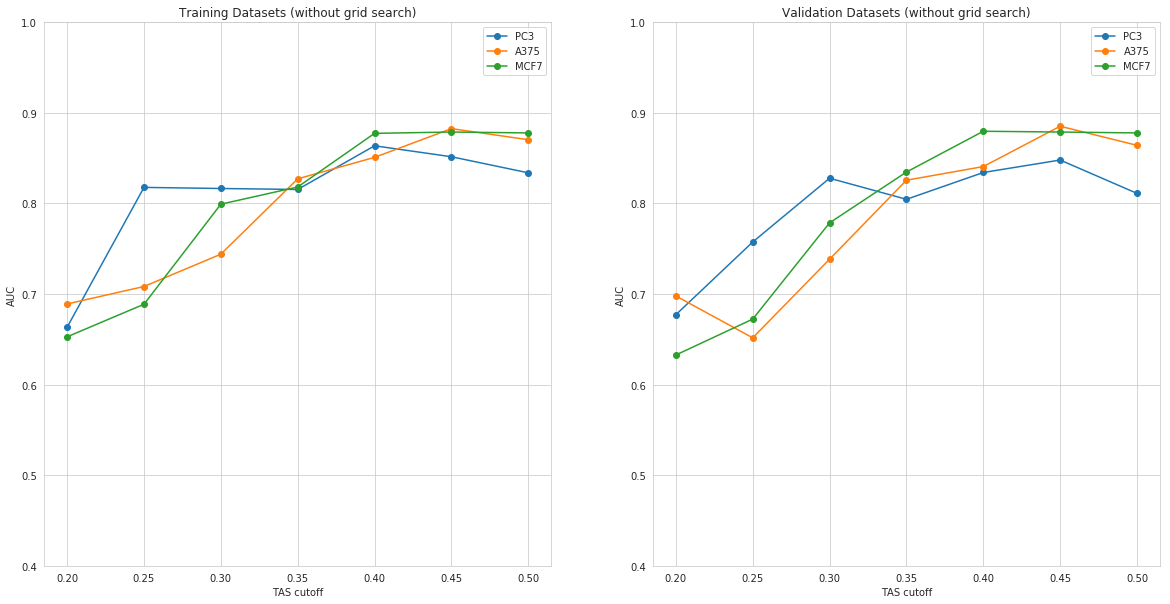

,TAS cutoff,PC3_train_AUC,PC3_val_AUC,A375_train_AUC,A375_val_AUC,MCF7_train_AUC,MCF7_val_AUC
0,0.20,0.663330,0.677148,0.689034,0.697848,0.652740,0.632675
1,0.25,0.817671,0.757400,0.708266,0.651633,0.688697,0.672295
2,0.30,0.816453,0.827778,0.743972,0.738412,0.799137,0.778557
3,0.35,0.815370,0.804505,0.827111,0.825589,0.818121,0.834596
4,0.40,0.863595,0.834107,0.850813,0.840650,0.877315,0.879630
5,0.45,0.851489,0.847868,0.882519,0.885175,0.878788,0.878788
6,0.50,0.833750,0.811061,0.870287,0.864103,0.877778,0.877778


In [25]:
# compare cross-validation average AUCs in training and validation datasets across all folds
compare_metric(cv_scores, "train_AUC", "val_AUC", "AUC", "Validation")

### b. Compare to Testing Datasets

In [26]:
### function to generate predictions on training and testing datasets for one cell line
def gen_pred(train_data, test_data, cell_line):
    ## initialize dictionaries to store the predictions
    train_pred = {}
    test_pred = {}
    ## iterate through all the tas cutoffs
    for tas_cutoff in tas_cutoffs:
        # store the training and testing datasets at that tas cutoff
        train_tas = train_data[cell_line][tas_cutoff]
        test_tas = test_data[cell_line][tas_cutoff]
        
        # train the model on all the training data
        cols = ["drug1 tas", "drug2 tas", "spearman corr"]
        X_train, y_train = train_tas[cols], train_tas["known ind"]
        lrm.fit(X_train, y_train)
        # add the predicted probabilities to the training dataset
        train_tas["predicted prob"] = lrm.predict_proba(X_train)[:, 1]
        # add the predicted probabilities to the testing dataset
        X_test = test_tas[cols]
        test_tas["predicted prob"] = lrm.predict_proba(X_test)[:, 1]
        
        # store the predictions in their respective dictionaries
        train_pred[tas_cutoff] = train_tas
        test_pred[tas_cutoff] = test_tas
        
    return train_pred, test_pred

In [27]:
### initialize dictionaries to store training and testing datasets with predictions
train_pred = {}
test_pred = {}

### iterate through each cell line
for cell_line in cell_lines:
    ## generate the predictions for that cell line
    train_tas, test_tas = gen_pred(train_data, test_data, cell_line)
    ## store the datasets to their respective dictionaries
    train_pred[cell_line] = train_tas
    test_pred[cell_line] = test_tas

train_pred["MCF7"][0.3].head()

,drug1,drug1 tas,drug2,drug2 tas,spearman corr,indication,known ind,predicted prob
1,sitagliptin,0.587846,5-aminolevulinic-acid,0.618329,0.750782,Glioma,False,0.821058
9,valrubicin,0.794730,doxorubicin,0.732233,0.725946,Wilms Tumor,False,0.826630
12,valrubicin,0.794730,doxorubicin,0.732233,0.725946,Urinary Bladder Neoplasms,True,0.826630
14,doxorubicin,0.732233,valrubicin,0.794730,0.725946,Urinary Bladder Neoplasms,True,0.845116
16,valrubicin,0.794730,doxorubicin,0.732233,0.725946,"Leukemia, Myeloid, Acute",False,0.826630


In [28]:
### function to determine the cell line weights
def gen_weights(train_pred, tas_cutoff):
    ## store the predictions for each cell line
    cols = ["drug1", "indication", "predicted prob", "known ind"]
    A375 = train_pred["A375"][tas_cutoff][cols]
    MCF7 = train_pred["MCF7"][tas_cutoff][cols]
    PC3 = train_pred["PC3"][tas_cutoff][cols]
        
    ## 1. generate the intersection dataset across all cell lines
    shared_data = pd.merge(A375, MCF7, on=["drug1", "indication"], how="inner", suffixes=("_A375", "_MCF7"))
    shared_data = pd.merge(shared_data, PC3, on=["drug1", "indication"], how="inner")
    shared_data.rename(columns={"predicted prob": "predicted prob_PC3"}, inplace=True)
    ##
        
    ## 2. calculate the cell line weights using another LRM trained on their predictions
    # define the inputs and outputs to the LRM
    X, y = shared_data.drop(columns=["drug1", "indication", "known ind"], axis=1), shared_data["known ind"].astype(int)
    # train the LRM of this data
    lrm.fit(X, y)
    # create a dictionary to store the weights
    tas_weights = {"MCF7": lrm.coef_[0][0],
                   "A375": lrm.coef_[0][1],
                   "PC3": lrm.coef_[0][2]}
    ##
    
    ## 3. generate the weighted average dataset (union across all cell lines)
    weighted_train = pd.merge(A375, MCF7, on=["drug1", "indication"], how="outer", suffixes=("_A375", "_MCF7"))
    weighted_train = pd.merge(weighted_train, PC3, on=["drug1", "indication"], how="outer")
    weighted_train.rename(columns={"predicted prob": "predicted prob_PC3",
                                   "known ind": "known ind_PC3"}, inplace=True)
    # combine the labelled outputs across all cell lines into one column
    cols = ["known ind_A375", "known ind_MCF7", "known ind_PC3"]
    weighted_train["known ind"] = weighted_train[cols].any(axis=1)
    weighted_train.drop(cols, axis=1, inplace=True)
    weighted_train.rename(columns={"predicted prob_A375": "A375",
                                   "predicted prob_MCF7": "MCF7",
                                   "predicted prob_PC3": "PC3",}, inplace=True)
    ##
        
    return weighted_train, tas_weights

In [29]:
### function to calculate the weighted average probability for one row
def weighted_avg(row, tas_weights):
    ## initialize variables to store the weighted sum and total weight
    total_weight = 0
    weighted_sum = 0
    ## iterate through each weight
    for col, weight in tas_weights.items():
        # if drug-indication is in cell line dataset
        if not pd.isnull(row[col]):
            # add the weights and values to their respectives variables
            weighted_sum += row[col] * weight
            total_weight += weight
    
    ## calculate the weighted probability
    return weighted_sum / total_weight

In [30]:
### function to generate the predictions for the weighted average model
def gen_weighted_avg(train_pred, test_pred):
    ## intialize dictionaries to store the data for the weighted average models
    weighted_train = {}
    weighted_test = {}
    cell_line_weights = {}
    
    ## iterate through each tas cutoff
    for tas_cutoff in tas_cutoffs:
        ## 1. get the weighted average predictions across the training datasets
        # generate the weights for that tas cutoff
        tas_weighted_train, tas_weights = gen_weights(train_pred, tas_cutoff)
        # add the weighted probabilities
        tas_weighted_train["predicted prob"] = tas_weighted_train.apply(weighted_avg, axis=1, tas_weights=tas_weights)
        # store the data in the dictionary
        weighted_train[tas_cutoff] = tas_weighted_train
        cell_line_weights[tas_cutoff] = tas_weights
        ##


        ## 2. get the weighted average predictions across the testing datasets
        # store the predictions for each cell line in the testing dataset
        cols = ["drug1", "indication", "predicted prob", "known ind"]
        A375 = test_pred["A375"][tas_cutoff][cols]
        MCF7 = test_pred["MCF7"][tas_cutoff][cols]
        PC3 = test_pred["PC3"][tas_cutoff][cols]
        # generate the weighted average dataset (union across all cell lines)
        tas_weighted_test = pd.merge(A375, MCF7, on=["drug1", "indication"], how="outer", suffixes=("_A375", "_MCF7"))
        tas_weighted_test = pd.merge(tas_weighted_test, PC3, on=["drug1", "indication"], how="outer")
        tas_weighted_test.rename(columns={"predicted prob": "predicted prob_PC3",
                                       "known ind": "known ind_PC3"}, inplace=True)
        # combine the labelled outputs across all cell lines into one column
        cols = ["known ind_A375", "known ind_MCF7", "known ind_PC3"]
        tas_weighted_test["known ind"] = tas_weighted_test[cols].any(axis=1)
        tas_weighted_test.drop(cols, axis=1, inplace=True)
        tas_weighted_test.rename(columns={"predicted prob_A375": "A375",
                                       "predicted prob_MCF7": "MCF7",
                                       "predicted prob_PC3": "PC3",}, inplace=True)
        # add the weighted probabilities
        tas_weighted_test["predicted prob"] = tas_weighted_test.apply(weighted_avg, axis=1, tas_weights=tas_weights)
        # store the data in the dictionary
        weighted_test[tas_cutoff] = tas_weighted_test
        ##
    
    return weighted_train, weighted_test, cell_line_weights

In [31]:
## redefine tas cutoffs
tas_cutoffs = [0.2, 0.25]

# calculate and store the weighted probabilities for training and testing datasets
train_pred["weighted avg"], test_pred["weighted avg"], cell_line_weights = gen_weighted_avg(train_pred, test_pred)
train_pred["weighted avg"][0.2].head()

,drug1,indication,A375,MCF7,PC3,known ind,predicted prob
0,pitavastatin,Myocardial Infarction,0.895108,NaN,NaN,False,0.895108
1,clofarabine,"Leukemia, Hairy Cell",0.882474,NaN,NaN,False,0.882474
2,clofarabine,"Carcinoma, Non-Small-Cell Lung",0.867371,NaN,NaN,False,0.867371
3,rebamipide,Attention Deficit Disorder with Hyperactivity,0.874102,NaN,NaN,False,0.874102
4,simvastatin,Hyperlipidemias,0.883403,NaN,0.847497,True,0.874171


In [32]:
cell_line_weights[0.2]

{'A375': 1.1607723098658709,
 'MCF7': 0.46833718753541415,
 'PC3': 0.401744026346513}

In [32]:
### function to generate AUCs for training and testing datasets for one cell line
def gen_train_test_scores(train_pred, test_pred, model):
    ## store all predictions into one dictionary
    pred = {"train": train_pred,
            "test": test_pred}
    
    ## initialize a dataframe to store the AUCs
    train_test_scores = pd.DataFrame()
    ## iterate through each tas cutoff
    for tas_cutoff in tas_cutoffs:
        ## initialize a dictionary to store the evaluation metric scores at tas cutoff
        tas_aucs = {}
        tas_aucs["TAS cutoff"] = tas_cutoff
        ## iterate through each dataset
        for dataset in pred:
            # get the model predictions and actual labels
            tas_data = pred[dataset][model][tas_cutoff]
            tas_pred = tas_data["predicted prob"]
            tas_actual = tas_data["known ind"]
            tas_pred_classes = (tas_pred > 0.5).astype(int)
            
            # store the evaluation metric scores
            tas_aucs[dataset + "_AUC"] = roc_auc_score(tas_actual, tas_pred)
            tas_aucs[dataset + "_F1 score"] = f1_score(tas_actual, tas_pred_classes)
            tas_aucs[dataset + "_precision"] = precision_score(tas_actual, tas_pred_classes)
            tas_aucs[dataset + "_recall"] = recall_score(tas_actual, tas_pred_classes)
        
            
        ## add the aucs at that tas cutoff to the dataframe
        train_test_scores = train_test_scores.append(tas_aucs, ignore_index=True)
        
    return train_test_scores

In [33]:
### initialize a dictionary to store all of the evaluation metrics for all cell lines
train_test_scores = {}

### iterate through each cell line
for model in train_pred.keys():
    ## generate and store the evaluation metric scores for cell line in dictionary
    train_test_scores[model] = gen_train_test_scores(train_pred, test_pred, model)
train_test_scores["MCF7"]

,TAS cutoff,test_AUC,test_F1 score,test_precision,test_recall,train_AUC,train_F1 score,train_precision,train_recall
0,0.20,0.675870,0.105565,0.057181,0.686170,0.729630,0.111628,0.060708,0.692308
1,0.25,0.697604,0.127139,0.069830,0.709091,0.765122,0.145161,0.080357,0.750000


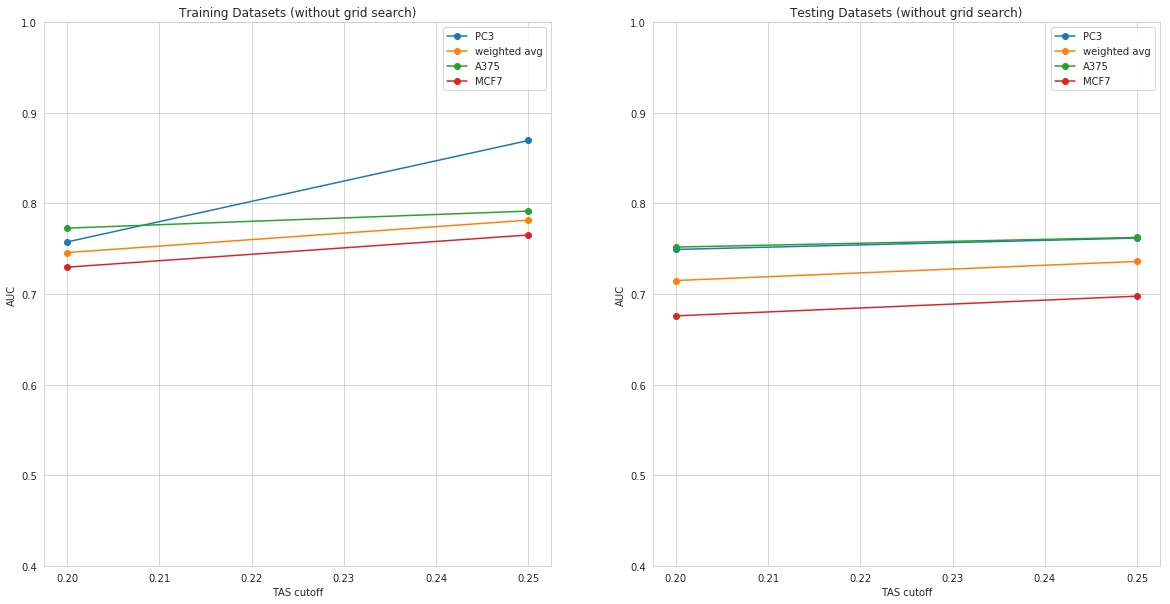

,TAS cutoff,PC3_train_AUC,PC3_test_AUC,weighted avg_train_AUC,weighted avg_test_AUC,A375_train_AUC,A375_test_AUC,MCF7_train_AUC,MCF7_test_AUC
0,0.20,0.757471,0.749187,0.745725,0.714857,0.772724,0.751786,0.729630,0.675870
1,0.25,0.869426,0.761755,0.781523,0.735985,0.791513,0.762430,0.765122,0.697604


In [34]:
# compare cross-validation average AUCs in training and testing datasets
# compare_metric(train_test_scores, "train_AUC", "test_AUC", "AUC", "Testing")

In [42]:
### function to generate ROC curve with AUCs for all model at TAS > 0.2
def gen_roc(tas_cutoff):
    ## create a new figure
    plt.figure(figsize=(10,10))
    models = ["A375", "MCF7", "PC3", "weighted avg"]
    ## iterate through each model
    for model in models:
        # store the training and testing dataset at that tas cutoff
        test = train_pred[model][tas_cutoff]
        # generate the ROC curve
        y_actual = test["known ind"]
        y_pred = test["predicted prob"]
        fpr, tpr, _ = roc_curve(y_actual, y_pred)
        auc = roc_auc_score(y_actual, y_pred)
        plt.plot(fpr, tpr, label = model + " (AUC = " + str(round(auc, 3)) + ")")
    
    ## add labels and legend
    plt.title("Receiver Operating Characteristic (ROC) Curve on Clinical Trials Data")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(zorder=0)
    plt.show()

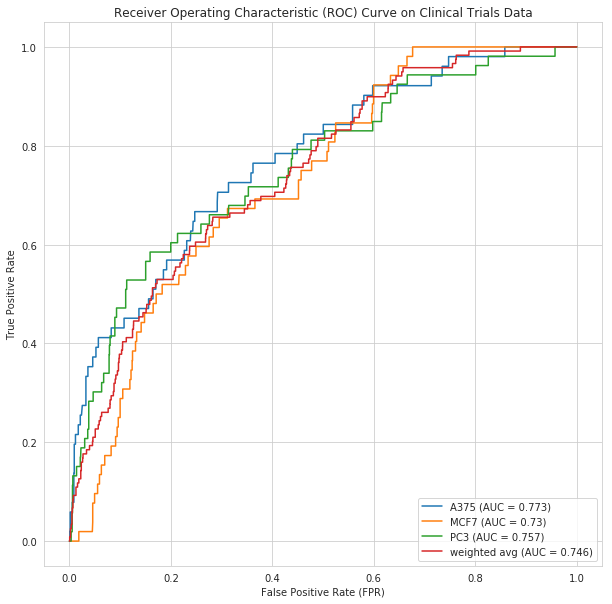

In [43]:
gen_roc(0.2)